# Explore here

In [63]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA

from pmdarima import auto_arima

import warnings

In [45]:
warnings.filterwarnings("ignore")

In [46]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"

df = pd.read_csv(url)

df.head(10)

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
5,2022-09-08 17:10:08.079328,60.081865
6,2022-09-09 17:10:08.079328,68.466704
7,2022-09-10 17:10:08.079328,67.765106
8,2022-09-11 17:10:08.079328,70.512261
9,2022-09-12 17:10:08.079328,74.656453


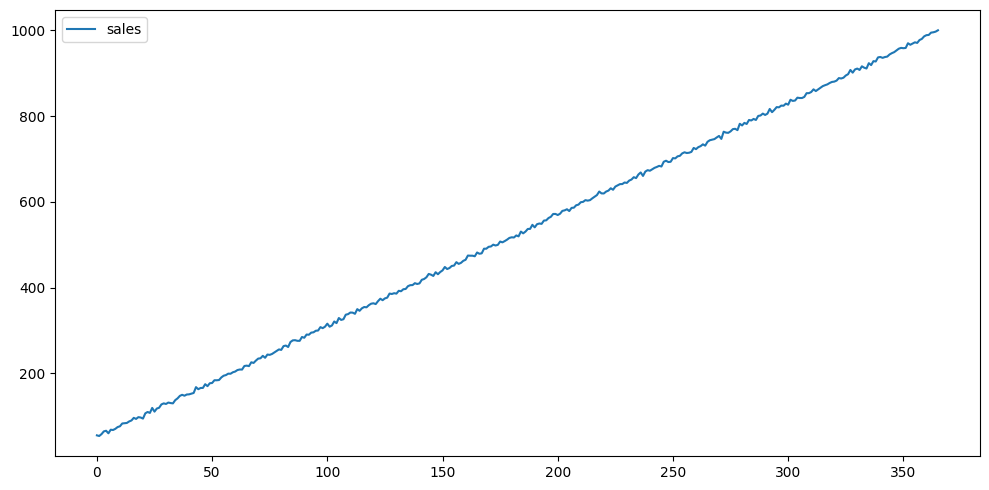

In [47]:
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)

plt.tight_layout()

plt.show()

Para trabajar mejor procederemos a modificar la columna date primero para transformala en formato fecha y luego eliminar las horas ya que en todas es la misma

In [48]:

df['date'] = pd.to_datetime(df['date'])
df['date'] = df['date'].dt.date

df

,date,sales
0,2022-09-03,55.292157
1,2022-09-04,53.803211
2,2022-09-05,58.141693
3,2022-09-06,64.530899
4,2022-09-07,66.013633
...,...,...
361,2023-08-30,989.600354
362,2023-08-31,994.987326
363,2023-09-01,995.814415
364,2023-09-02,997.350214


hacemos indice a la fecha para trabajar con una columna.

In [49]:
df = df.set_index('date')

df.head()

,sales
date,
2022-09-03,55.292157
2022-09-04,53.803211
2022-09-05,58.141693
2022-09-06,64.530899
2022-09-07,66.013633


In [50]:
decomposition = seasonal_decompose(df, period = 12)
decomposition

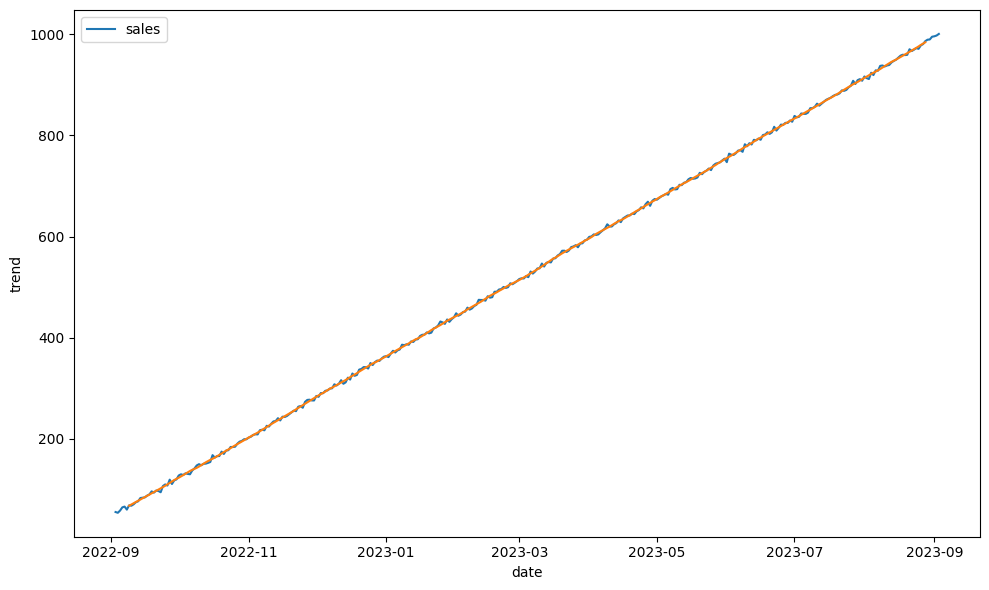

In [51]:
trend = decomposition.trend

fig, axis = plt.subplots(figsize = (10, 6))

sns.lineplot(data = df)
sns.lineplot(data = trend)

plt.tight_layout()

plt.show()

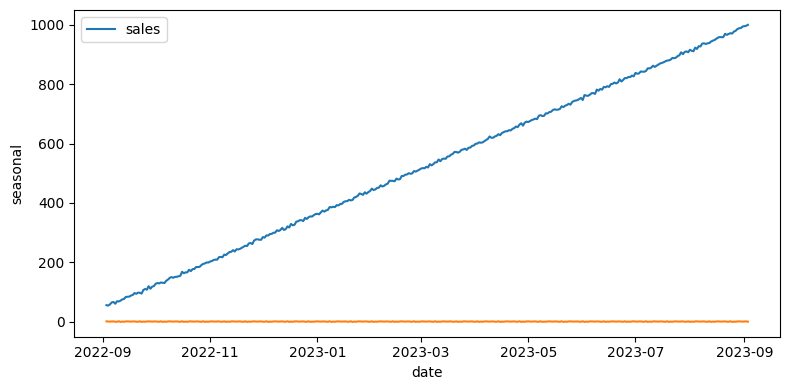

In [52]:
seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize = (8, 4))

sns.lineplot(data = df) 
sns.lineplot(data = seasonal)

plt.tight_layout()

plt.show()

In [53]:
def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

In [54]:
test_stationarity(df)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

In [56]:
df_dif = pd.read_csv(url)

df_dif['date'] = pd.to_datetime(df_dif['date'])
df_dif['date'] = df_dif['date'].dt.date

df_dif = df_dif.set_index('date')

df_dif['dif_sales'] = df_dif['sales'].diff().dropna()

df_sales_dif = df_dif['dif_sales']
df_sales_dif.dropna(inplace=True)

df_sales_dif

date
2022-09-04   -1.488946
2022-09-05    4.338482
2022-09-06    6.389205
2022-09-07    1.482734
2022-09-08   -5.931768
                ...   
2023-08-30    0.518681
2023-08-31    5.386972
2023-09-01    0.827090
2023-09-02    1.535798
2023-09-03    3.132571
Name: dif_sales, Length: 365, dtype: float64

In [57]:
test_stationarity(df_sales_dif)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -9.430263e+00
p-value                        5.212954e-16
#Lags Used                     1.200000e+01
Number of Observations Used    3.520000e+02
Critical Value (1%)           -3.449065e+00
Critical Value (5%)           -2.869786e+00
Critical Value (10%)          -2.571163e+00
dtype: float64

Vemos que ahora el valor es infimo de 5.21e-16, asi que podemos tomarlo como estacionaria

# Analisis de variabilidad


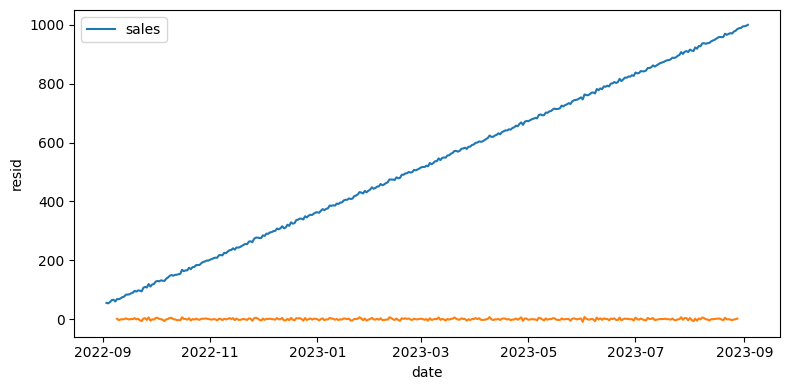

In [58]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize = (8, 4))

sns.lineplot(data = df)
sns.lineplot(data = residual)

plt.tight_layout()

plt.show()

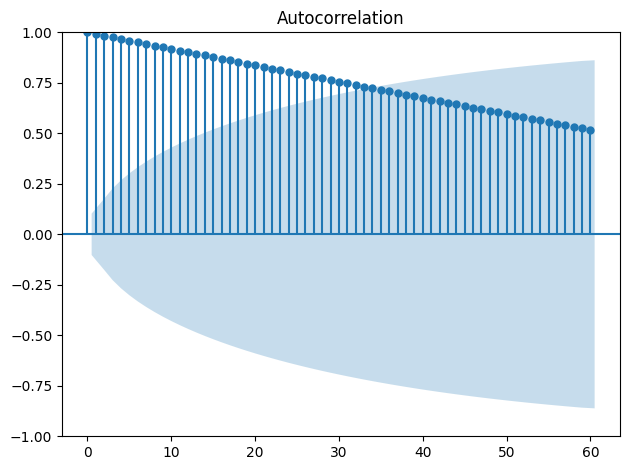

In [61]:
plot_acf(df, lags=60)

plt.tight_layout()

plt.show()

Podemos observar que hay mucha correlacion unos con otros a medida que pasa el tiempo, por lo que tiene mucha dependencia temporal, los valores pasados influyen muchisimo en los futuros.

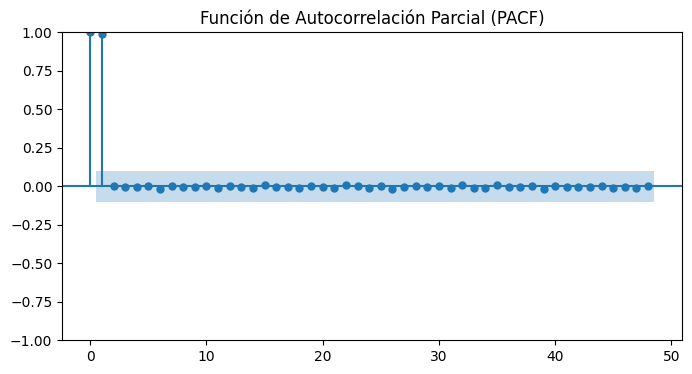

In [64]:
# Graficar PACF
plt.figure(figsize=(8, 4))
plot_pacf(df, lags=48, ax=plt.gca())
plt.title('Función de Autocorrelación Parcial (PACF)')
plt.show()

In [67]:
df_dif = pd.read_csv(url)

df_dif['date'] = pd.to_datetime(df_dif['date'])
df_dif['date'] = df_dif['date'].dt.date

df_dif = df_dif.set_index("date")

ts = df_dif["sales"]

# Diferenciación de primer orden
df_dif1 = ts.diff().dropna()

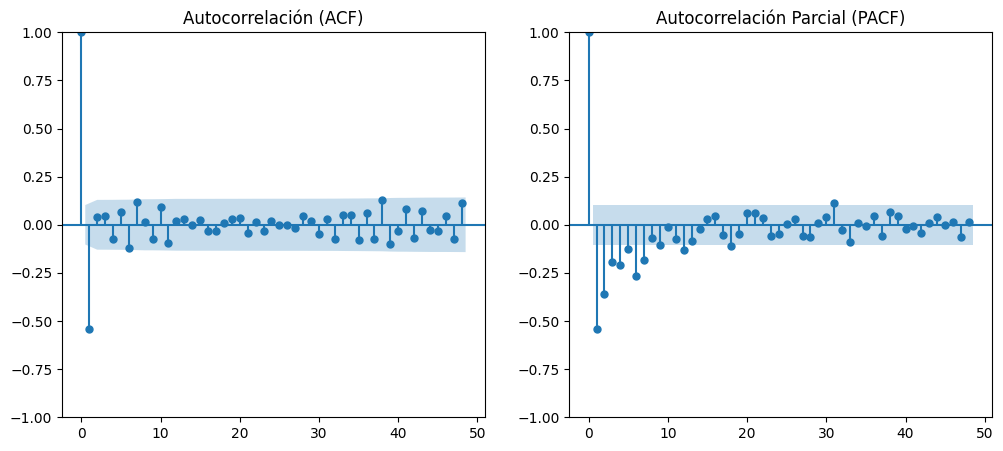

In [68]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ACF para determinar q
plot_acf(df_dif1, lags=48, ax=ax[0])
ax[0].set_title("Autocorrelación (ACF)")

# PACF para determinar p
plot_pacf(df_dif1, lags=48, ax=ax[1])
ax[1].set_title("Autocorrelación Parcial (PACF)")

plt.show()

In [69]:
p = 1
d = 1
q = 1

modelo_arima = ARIMA(df, order=(p,d,q))

resultado_arima = modelo_arima.fit()

In [72]:
# Pronóstico para los próximos 12 meses
predicciones = resultado_arima.predict(start=len(df), end=len(df)+11)
predicciones

2023-09-04    1003.053436
2023-09-05    1005.624086
2023-09-06    1008.194735
2023-09-07    1010.765384
2023-09-08    1013.336032
2023-09-09    1015.906679
2023-09-10    1018.477325
2023-09-11    1021.047970
2023-09-12    1023.618615
2023-09-13    1026.189259
2023-09-14    1028.759902
2023-09-15    1031.330544
Freq: D, Name: predicted_mean, dtype: float64

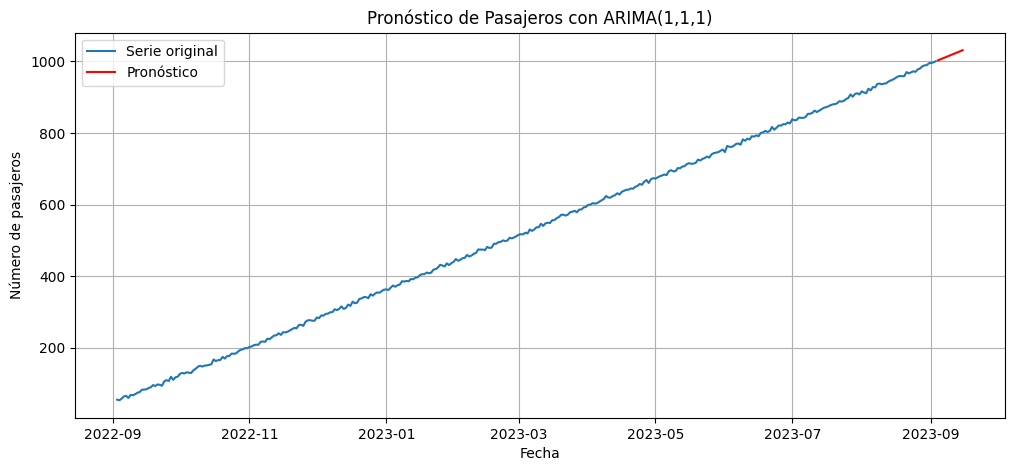

In [73]:
# Graficar pronóstico
plt.figure(figsize=(12,5))
plt.plot(df, label='Serie original')
plt.plot(predicciones, label='Pronóstico', color='red')
plt.title("Pronóstico de Pasajeros con ARIMA(1,1,1)")
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")
plt.legend()
plt.grid(True)
plt.show()

Podemos obervar que la prediccion que se realizo va a corde a la grafica de ventas que se tiene

In [74]:
model = auto_arima(df, seasonal = True, trace = True, m = 12)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1847.126, Time=1.74 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2096.542, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1972.853, Time=0.21 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.95 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2209.657, Time=0.01 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=1844.700, Time=1.34 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=1843.161, Time=0.58 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=1845.092, Time=1.27 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : AIC=1843.586, Time=0.21 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=1841.532, Time=0.35 sec
 ARIMA(2,1,1)(1,0,0)[12] intercept   : AIC=1843.435, Time=1.79 sec
 ARIMA(2,1,1)(0,0,1)[12] intercept   : AIC=1843.433, Time=1.43 sec
 ARIMA(2,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=1.77 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=1839.552, Time=0.24 sec
 ARIMA(1,1,1)(1,0,0)[12] inte

In [75]:
forecast = model.predict(12)
forecast

2023-09-04    1002.158148
2023-09-05    1004.831669
2023-09-06    1007.423289
2023-09-07    1010.021630
2023-09-08    1012.619419
2023-09-09    1015.217254
2023-09-10    1017.815084
2023-09-11    1020.412915
2023-09-12    1023.010746
2023-09-13    1025.608577
2023-09-14    1028.206409
2023-09-15    1030.804240
Freq: D, dtype: float64

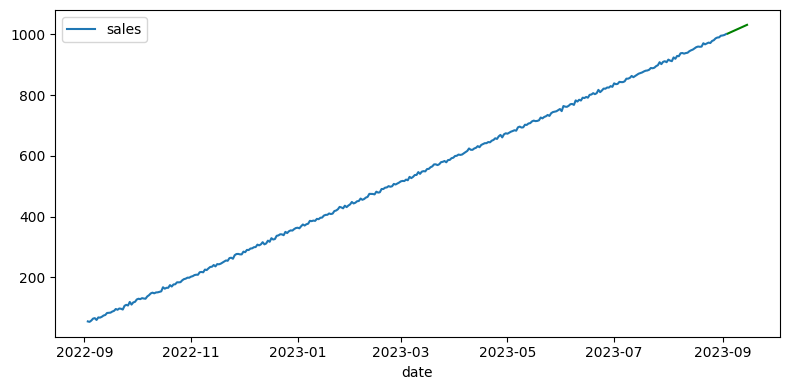

In [76]:
fig, axis = plt.subplots(figsize = (8, 4))

sns.lineplot(data = df)
sns.lineplot(data = forecast, c = "green")

plt.tight_layout()

plt.show()

Adaptando mejor para ver el mejor modelo, podemos ver que la prediccion que se uso es la mas acertada

In [77]:
from pickle import dump

dump(model, open("../models/modelo_arima.pkl", "wb"))

